excess data in 'kern' subtable: 6 bytes
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


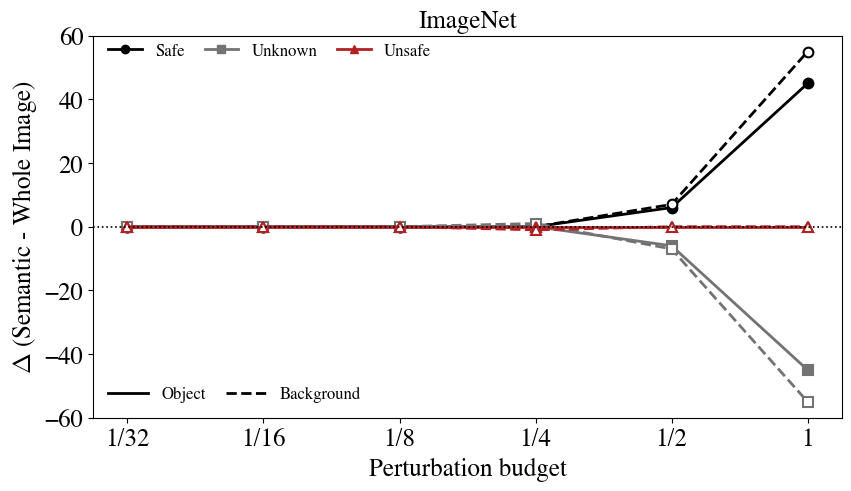

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import shutil
from matplotlib.lines import Line2D

LATEX_AVAILABLE = shutil.which("latex") is not None
if LATEX_AVAILABLE and shutil.which("kpsewhich") is not None:
    latex_fmt = subprocess.run(
        ["kpsewhich", "latex.fmt"],
        capture_output=True,
        text=True,
        check=False,
    )
    LATEX_AVAILABLE = latex_fmt.returncode == 0 and bool(latex_fmt.stdout.strip())
elif LATEX_AVAILABLE:
    LATEX_AVAILABLE = False

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "DejaVu Serif"],
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

if LATEX_AVAILABLE:
    plt.rcParams.update({
        "text.usetex": True,
        "text.latex.preamble": r"\\usepackage{amsmath}\\usepackage{bm}",
    })
else:
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
    })

label_fs = 18
tick_fs = 18
legend_fs = 15

budget_labels = ["1/32", "1/16", "1/8", "1/4", "1/2", "1"]
x = np.arange(len(budget_labels))

series = {
    ("Safe", "Object"): [0, 0, 0, 0, 6, 45],
    ("Safe", "Background"): [0, 0, 0, 0, 7, 55],
    ("Unknown", "Object"): [0, 0, 0, 0, -6, -45],
    ("Unknown", "Background"): [0, 0, 0, 1, -7, -55],
    ("Unsafe", "Object"): [0, 0, 0, 0, 0, 0],
    ("Unsafe", "Background"): [0, 0, 0, -1, 0, 0],
}

outcome_style = {
    "Safe": {"color": "black", "marker": "o"},
    "Unknown": {"color": "0.45", "marker": "s"},
    "Unsafe": {"color": "#B22222", "marker": "^"},
}

region_style = {
    "Object": {"linestyle": "-", "markerfacecolor": None},
    "Background": {"linestyle": "--", "markerfacecolor": "white"},
}

def plot_l0(ax, title):
    for (outcome, region), values in series.items():
        markerfacecolor = outcome_style[outcome]["color"]
        if region_style[region]["markerfacecolor"] is not None:
            markerfacecolor = region_style[region]["markerfacecolor"]

        ax.plot(
            x,
            values,
            linewidth=2.0,
            color=outcome_style[outcome]["color"],
            linestyle=region_style[region]["linestyle"],
            marker=outcome_style[outcome]["marker"],
            markersize=7.0,
            markerfacecolor=markerfacecolor,
            markeredgecolor=outcome_style[outcome]["color"],
            markeredgewidth=1.5,
        )

    all_values = np.array([value for values in series.values() for value in values], dtype=float)
    y_limit = np.max(np.abs(all_values)) + 5

    ax.axhline(y=0.0, color="black", linestyle=":", linewidth=1.2)
    ax.set_title(title, fontsize=label_fs)
    ax.set_xlabel("Perturbation budget", fontsize=label_fs)
    ax.set_xticks(x)
    ax.set_xticklabels(budget_labels)
    ax.set_ylim(-y_limit, y_limit)
    ax.tick_params(axis="both", labelsize=tick_fs)

    ax.set_ylabel(r"$\Delta$ (Semantic - Whole Image)", fontsize=label_fs)

    # ax.grid(linestyle="--", linewidth=0.5, alpha=0.6)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)


fig, ax = plt.subplots(1, 1, figsize=(8.4, 4.8), sharex=False, sharey=False, constrained_layout=True)

plot_l0(ax, "ImageNet")

outcome_handles = [
    Line2D(
        [0],
        [0],
        color=style["color"],
        marker=style["marker"],
        linestyle="-",
        linewidth=2.0,
        label=outcome,
    )
    for outcome, style in outcome_style.items()
]

region_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linestyle=style["linestyle"],
        linewidth=2.0,
        label=region,
    )
    for region, style in region_style.items()
]

outcome_legend = ax.legend(
    handles=outcome_handles,
    frameon=False,
    ncol=3,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.02),
    columnspacing=1.2,
    handlelength=2.0,
)
ax.add_artist(outcome_legend)

ax.legend(
    handles=region_handles,
    frameon=False,
    ncol=2,
    loc="lower left",
    handlelength=2.4,
    columnspacing=1.2,
)

fig.savefig("imagenet_l0_semantic_vs_global.pdf", bbox_inches="tight")
plt.show()